## Importing necessary libraries

In [ ]:
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import MaxPooling1D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.layers import LSTM
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf





In [ ]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import regularizers
import xgboost as xgb
from sklearn.decomposition import PCA
from sklearn import tree
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn import metrics
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
pd.set_option('display.max_columns',None)
warnings.filterwarnings('ignore')
%matplotlib inline

## Exploring the dataset

In [ ]:

import os
import kagglehub
import pandas as pd

# 1. Configurer le token
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_19936b2cef7e655ec545add1d32e33e3'

# 2. Télécharger le dataset
print("Téléchargement du dataset...")
path = kagglehub.dataset_download("dhoogla/cicddos2019")
print(f"Dataset disponible dans : {path}")

# 3. Lister les fichiers
import os
files = os.listdir(path)
print(f"Fichiers disponibles : {files[:5]}...")

# 4. Charger un fichier CSV (exemple)
csv_files = [f for f in files if f.endswith('.csv')]
if csv_files:
    df = pd.read_csv(os.path.join(path, csv_files[0]), nrows=10000)
    print(f" DataFrame chargé : {df.shape}")

Téléchargement du dataset...
Using Colab cache for faster access to the 'cicddos2019' dataset.
✅ Dataset disponible dans : /kaggle/input/cicddos2019
Fichiers disponibles : ['Syn-training.parquet', 'UDPLag-testing.parquet', 'NetBIOS-testing.parquet', 'Portmap-training.parquet', 'Syn-testing.parquet']...


In [ ]:


import glob
import pandas as pd

parquet_files = glob.glob(os.path.join(path, "**/*.parquet"), recursive=True)
csv_files     = glob.glob(os.path.join(path, "**/*.csv"),     recursive=True)

print(f"Parquet : {len(parquet_files)} fichiers")
print(f"CSV     : {len(csv_files)} fichiers")

if len(parquet_files) > 0:
    fichiers = parquet_files
    lire     = pd.read_parquet
    print(" Utilisation des fichiers Parquet")
elif len(csv_files) > 0:
    fichiers = csv_files
    lire     = pd.read_csv
    print("→ Utilisation des fichiers CSV")
else:
    print("❌Aucun fichier trouvé")

# Charger
donnee = []
for file in fichiers:
    df = lire(file)
    donnee.append(df)
    print(f"{os.path.basename(file)} : {len(df):,} lignes")

df_master = pd.concat(donnee, ignore_index=True)
print(f"\nDataFrame final : {df_master.shape}")

Parquet : 17 fichiers
CSV     : 0 fichiers
→ Utilisation des fichiers Parquet
✅ Syn-training.parquet : 70,336 lignes
✅ UDPLag-testing.parquet : 12,465 lignes
✅ NetBIOS-testing.parquet : 2,225 lignes
✅ Portmap-training.parquet : 5,105 lignes
✅ Syn-testing.parquet : 907 lignes
✅ MSSQL-testing.parquet : 8,083 lignes
✅ SNMP-testing.parquet : 4,018 lignes
✅ UDPLag-training.parquet : 12,639 lignes
✅ NTP-testing.parquet : 134,674 lignes
✅ LDAP-testing.parquet : 2,831 lignes
✅ UDP-training.parquet : 17,770 lignes
✅ NetBIOS-training.parquet : 1,631 lignes
✅ DNS-testing.parquet : 6,703 lignes
✅ UDP-testing.parquet : 12,462 lignes
✅ LDAP-training.parquet : 6,715 lignes
✅ TFTP-testing.parquet : 121,833 lignes
✅ MSSQL-training.parquet : 10,974 lignes

📊 DataFrame final : (431371, 78)


In [ ]:
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 431371 entries, 0 to 431370
Data columns (total 78 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Protocol                  431371 non-null  int8   
 1   Flow Duration             431371 non-null  int32  
 2   Total Fwd Packets         431371 non-null  int32  
 3   Total Backward Packets    431371 non-null  int16  
 4   Fwd Packets Length Total  431371 non-null  float32
 5   Bwd Packets Length Total  431371 non-null  float32
 6   Fwd Packet Length Max     431371 non-null  float32
 7   Fwd Packet Length Min     431371 non-null  float32
 8   Fwd Packet Length Mean    431371 non-null  float32
 9   Fwd Packet Length Std     431371 non-null  float32
 10  Bwd Packet Length Max     431371 non-null  float32
 11  Bwd Packet Length Min     431371 non-null  float32
 12  Bwd Packet Length Mean    431371 non-null  float32
 13  Bwd Packet Length Std     431371 non-null  f

In [ ]:
df = df_master.copy()

In [ ]:
df.shape

(431371, 78)

In [ ]:
data = df.copy()

In [ ]:
data.shape

(431371, 78)

In [ ]:
col_name = {
'Flow ID': 'Flow ID',
'Source IP': 'Source IP',
'Src IP':  'Source IP',
'Source Port': 'Source Port',
'Src Port': 'Source Port',
'Destination IP': 'Destination IP',
'Dst IP': 'Destination IP',
'Destination Port': 'Destination Port',
'Dst Port': 'Destination Port',
'Protocol': 'Protocol',
'Timestamp': 'Timestamp',
'Flow Duration': 'Flow Duration',
'Total Fwd Packets': 'Total Fwd Packets',
'Tot Fwd Pkts': 'Total Fwd Packets',
'Total Backward Packets': 'Total Backward Packets',
'Tot Bwd Pkts': 'Total Backward Packets',
'Total Length of Fwd Packets': 'Fwd Packets Length Total',
'TotLen Fwd Pkts': 'Fwd Packets Length Total',
'Total Length of Bwd Packets': 'Bwd Packets Length Total',
'TotLen Bwd Pkts': 'Bwd Packets Length Total',
'Fwd Packet Length Max': 'Fwd Packet Length Max',
'Fwd Pkt Len Max': 'Fwd Packet Length Max',
'Fwd Packet Length Min': 'Fwd Packet Length Min',
'Fwd Pkt Len Min': 'Fwd Packet Length Min',
'Fwd Packet Length Mean': 'Fwd Packet Length Mean',
'Fwd Pkt Len Mean': 'Fwd Packet Length Mean',
'Fwd Packet Length Std': 'Fwd Packet Length Std',
'Fwd Pkt Len Std': 'Fwd Packet Length Std',
'Bwd Packet Length Max': 'Bwd Packet Length Max',
'Bwd Pkt Len Max': 'Bwd Packet Length Max',
'Bwd Packet Length Min': 'Bwd Packet Length Min',
'Bwd Pkt Len Min': 'Bwd Packet Length Min',
'Bwd Packet Length Mean': 'Bwd Packet Length Mean',
'Bwd Pkt Len Mean': 'Bwd Packet Length Mean',
'Bwd Packet Length Std': 'Bwd Packet Length Std',
'Bwd Pkt Len Std': 'Bwd Packet Length Std',
'Flow Bytes/s': 'Flow Bytes/s',
'Flow Byts/s': 'Flow Bytes/s',
'Flow Packets/s': 'Flow Packets/s',
'Flow Pkts/s': 'Flow Packets/s',
'Flow IAT Mean': 'Flow IAT Mean',
'Flow IAT Std': 'Flow IAT Std',
'Flow IAT Max': 'Flow IAT Max',
'Flow IAT Min': 'Flow IAT Min',
'Fwd IAT Total': 'Fwd IAT Total',
'Fwd IAT Tot': 'Fwd IAT Total',
'Fwd IAT Mean': 'Fwd IAT Mean',
'Fwd IAT Std': 'Fwd IAT Std',
'Fwd IAT Max': 'Fwd IAT Max',
'Fwd IAT Min': 'Fwd IAT Min',
'Bwd IAT Total': 'Bwd IAT Total',
'Bwd IAT Tot': 'Bwd IAT Total',
'Bwd IAT Mean': 'Bwd IAT Mean',
'Bwd IAT Std': 'Bwd IAT Std',
'Bwd IAT Max': 'Bwd IAT Max',
'Bwd IAT Min': 'Bwd IAT Min',
'Fwd PSH Flags': 'Fwd PSH Flags',
'Bwd PSH Flags': 'Bwd PSH Flags',
'Fwd URG Flags': 'Fwd URG Flags',
'Bwd URG Flags': 'Bwd URG Flags',
'Fwd Header Length': 'Fwd Header Length',
'Fwd Header Len': 'Fwd Header Length',
'Bwd Header Length': 'Bwd Header Length',
'Bwd Header Len': 'Bwd Header Length',
'Fwd Packets/s': 'Fwd Packets/s',
'Fwd Pkts/s': 'Fwd Packets/s',
'Bwd Packets/s': 'Bwd Packets/s',
'Bwd Pkts/s': 'Bwd Packets/s',
'Min Packet Length': 'Packet Length Min',
'Pkt Len Min': 'Packet Length Min',
'Max Packet Length': 'Packet Length Max',
'Pkt Len Max': 'Packet Length Max',
'Packet Length Mean': 'Packet Length Mean',
'Pkt Len Mean': 'Packet Length Mean',
'Packet Length Std': 'Packet Length Std',
'Pkt Len Std': 'Packet Length Std',
'Packet Length Variance': 'Packet Length Variance',
'Pkt Len Var': 'Packet Length Variance',
'FIN Flag Count': 'FIN Flag Count',
'FIN Flag Cnt': 'FIN Flag Count',
'SYN Flag Count': 'SYN Flag Count',
'SYN Flag Cnt': 'SYN Flag Count',
'RST Flag Count': 'RST Flag Count',
'RST Flag Cnt': 'RST Flag Count',
'PSH Flag Count': 'PSH Flag Count',
'PSH Flag Cnt': 'PSH Flag Count',
'ACK Flag Count': 'ACK Flag Count',
'ACK Flag Cnt': 'ACK Flag Count',
'URG Flag Count': 'URG Flag Count',
'URG Flag Cnt': 'URG Flag Count',
'CWE Flag Count': 'CWE Flag Count',
'CWE Flag Cnt': 'CWE Flag Count',
'ECE Flag Count': 'ECE Flag Count',
'ECE Flag Cnt': 'ECE Flag Count',
'Down/Up Ratio': 'Down/Up Ratio',
'Average Packet Size': 'Avg Packet Size',
'Pkt Size Avg': 'Avg Packet Size',
'Avg Fwd Segment Size': 'Avg Fwd Segment Size',
'Fwd Seg Size Avg': 'Avg Fwd Segment Size',
'Avg Bwd Segment Size': 'Avg Bwd Segment Size',
'Bwd Seg Size Avg': 'Avg Bwd Segment Size',
'Fwd Avg Bytes/Bulk': 'Fwd Avg Bytes/Bulk',
'Fwd Byts/b Avg': 'Fwd Avg Bytes/Bulk',
'Fwd Avg Packets/Bulk': 'Fwd Avg Packets/Bulk',
'Fwd Pkts/b Avg': 'Fwd Avg Packets/Bulk',
'Fwd Avg Bulk Rate': 'Fwd Avg Bulk Rate',
'Fwd Blk Rate Avg': 'Fwd Avg Bulk Rate',
'Bwd Avg Bytes/Bulk': 'Bwd Avg Bytes/Bulk',
'Bwd Byts/b Avg': 'Bwd Avg Bytes/Bulk',
'Bwd Avg Packets/Bulk': 'Bwd Avg Packets/Bulk',
'Bwd Pkts/b Avg': 'Bwd Avg Packets/Bulk',
'Bwd Avg Bulk Rate': 'Bwd Avg Bulk Rate',
'Bwd Blk Rate Avg': 'Bwd Avg Bulk Rate',
'Subflow Fwd Packets': 'Subflow Fwd Packets',
'Subflow Fwd Pkts': 'Subflow Fwd Packets',
'Subflow Fwd Bytes': 'Subflow Fwd Bytes',
'Subflow Fwd Byts': 'Subflow Fwd Bytes',
'Subflow Bwd Packets': 'Subflow Bwd Packets',
'Subflow Bwd Pkts': 'Subflow Bwd Packets',
'Subflow Bwd Bytes': 'Subflow Bwd Bytes',
'Subflow Bwd Byts': 'Subflow Bwd Bytes',
'Init_Win_bytes_forward': 'Init Fwd Win Bytes',
'Init Fwd Win Byts': 'Init Fwd Win Bytes',
'Init_Win_bytes_backward': 'Init Bwd Win Bytes',
'Init Bwd Win Byts': 'Init Bwd Win Bytes',
'act_data_pkt_fwd': 'Fwd Act Data Packets',
'Fwd Act Data Pkts': 'Fwd Act Data Packets',
'min_seg_size_forward': 'Fwd Seg Size Min',
'Fwd Seg Size Min': 'Fwd Seg Size Min',
'Active Mean': 'Active Mean',
'Active Std': 'Active Std',
'Active Max': 'Active Max',
'Active Min': 'Active Min',
'Idle Mean': 'Idle Mean',
'Idle Std': 'Idle Std',
'Idle Max': 'Idle Max',
'Idle Min': 'Idle Min',
'Label': 'Label'
}

In [ ]:
#data.columns = data.columns.str.strip()
#data.rename(columns=col_name, inplace=True)

In [ ]:
data

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Packet Length Min,Packet Length Max,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Avg Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init Fwd Win Bytes,Init Bwd Win Bytes,Fwd Act Data Packets,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6,105,2,2,12.0,12.0,6.0,6.0,6.000000,0.000000,6.0,6.0,6.0,0.000000,2.285714e+05,3.809524e+04,3.500000e+01,5.975784e+01,104.0,0.0,1.0,1.000000e+00,0.000000e+00,1.0,1.0,0.0,0.000000,0.000000,0.0,0.0,0,0,0,0,40,40,1.904762e+04,19047.619141,6.0,6.0,6.000000,0.000000,0.000000,0,0,0,0,1,0,0,0,1.0,7.500000,6.000000,6.0,0,0,0,0,0,0,2,12,2,12,5840,0,1,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Syn
1,6,1,2,0,12.0,0.0,6.0,6.0,6.000000,0.000000,0.0,0.0,0.0,0.000000,1.200000e+07,2.000000e+06,1.000000e+00,0.000000e+00,1.0,1.0,1.0,1.000000e+00,0.000000e+00,1.0,1.0,0.0,0.000000,0.000000,0.0,0.0,0,0,0,0,40,0,2.000000e+06,0.000000,6.0,6.0,6.000000,0.000000,0.000000,0,0,0,0,1,0,0,0,0.0,9.000000,6.000000,0.0,0,0,0,0,0,0,2,12,0,0,5840,-1,1,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Syn
2,6,55295858,8,0,48.0,0.0,6.0,6.0,6.000000,0.000000,0.0,0.0,0.0,0.000000,8.680578e-01,1.446763e-01,7.899408e+06,1.021020e+07,22000140.0,1.0,55295856.0,7.899408e+06,1.021020e+07,22000140.0,1.0,0.0,0.000000,0.000000,0.0,0.0,0,0,0,0,160,0,1.446763e-01,0.000000,6.0,6.0,6.000000,0.000000,0.000000,0,0,0,0,1,0,0,0,0.0,6.750000,6.000000,0.0,0,0,0,0,0,0,8,48,0,0,5840,-1,7,20,1.0,0.0,1.0,1.0,18431952.0,4641289.0,22000140.0,13184826.0,Syn
3,6,49,2,0,12.0,0.0,6.0,6.0,6.000000,0.000000,0.0,0.0,0.0,0.000000,2.448980e+05,4.081633e+04,4.900000e+01,0.000000e+00,49.0,49.0,49.0,4.900000e+01,0.000000e+00,49.0,49.0,0.0,0.000000,0.000000,0.0,0.0,0,0,0,0,40,0,4.081633e+04,0.000000,6.0,6.0,6.000000,0.000000,0.000000,0,0,0,0,1,0,0,0,0.0,9.000000,6.000000,0.0,0,0,0,0,0,0,2,12,0,0,5840,-1,1,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Syn
4,6,109,2,2,12.0,12.0,6.0,6.0,6.000000,0.000000,6.0,6.0,6.0,0.000000,2.201835e+05,3.669725e+04,3.633333e+01,6.033517e+01,106.0,1.0,1.0,1.000000e+00,0.000000e+00,1.0,1.0,2.0,2.000000,0.000000,2.0,2.0,0,0,0,0,40,40,1.834862e+04,18348.623047,6.0,6.0,6.000000,0.000000,0.000000,0,0,0,0,1,0,0,0,1.0,7.500000,6.000000,6.0,0,0,0,0,0,0,2,12,2,12,5840,0,1,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Syn
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
431366,6,91401,2,2,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000e+00,4.376320e+01,3.046700e+04,5.276779e+04,91398.0,1.0,2.0,2.000000e+00,0.000000e+00,2.0,2.0,1.0,1.000000,0.000000,1.0,1.0,0,0,0,0,64,64,2.188160e+01,21.881599,0.0,0.0,0.000000,0.000000,0.000000,0,0,0,0,0,1,0,0,1.0,0.000000,0.000000,0.0,0,0,0,0,0,0,2,0,2,0,304,116,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
431367,6,65464,2,2,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0

In [ ]:
df["Label"].unique()

array(['Syn', 'Benign', 'UDP-lag', 'WebDDoS', 'DrDoS_NetBIOS', 'Portmap',
       'DrDoS_MSSQL', 'DrDoS_SNMP', 'UDP', 'UDPLag', 'DrDoS_NTP',
       'DrDoS_LDAP', 'MSSQL', 'NetBIOS', 'DrDoS_DNS', 'DrDoS_UDP', 'LDAP',
       'TFTP'], dtype=object)

In [ ]:
# =========================================================
# CRÉATION DE OUTCOME (BINAIRE)
# =========================================================

# 1. Vérifier la distribution originale
print("Distribution originale:")
print(data['Label'].value_counts())

# 2. Créer outcome (0 = Benign, 1 = tout le reste)
data['outcome'] = (data['Label'] != 'Benign').astype(int)

# 3. Vérifier
print("\nDistribution binaire:")
print(data['outcome'].value_counts())

# 4. Voir la correspondance
print("\nCorrespondance Label vs outcome:")
print(data.groupby(['Label', 'outcome']).size())

Distribution originale:
Label
DrDoS_NTP        121368
TFTP              98917
Benign            97831
Syn               49373
UDP               18090
DrDoS_UDP         10420
UDP-lag            8872
MSSQL              8523
DrDoS_MSSQL        6212
DrDoS_DNS          3669
DrDoS_SNMP         2717
LDAP               1906
DrDoS_LDAP         1440
Portmap             685
NetBIOS             644
DrDoS_NetBIOS       598
UDPLag               55
WebDDoS              51
Name: count, dtype: int64

Distribution binaire:
outcome
1    333540
0     97831
Name: count, dtype: int64

Correspondance Label vs outcome:
Label          outcome
Benign         0           97831
DrDoS_DNS      1            3669
DrDoS_LDAP     1            1440
DrDoS_MSSQL    1            6212
DrDoS_NTP      1          121368
DrDoS_NetBIOS  1             598
DrDoS_SNMP     1            2717
DrDoS_UDP      1           10420
LDAP           1            1906
MSSQL          1            8523
NetBIOS        1             644
Portmap    

## Preprocessing the data

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 431371 entries, 0 to 431370
Data columns (total 79 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Protocol                  431371 non-null  int8   
 1   Flow Duration             431371 non-null  int32  
 2   Total Fwd Packets         431371 non-null  int32  
 3   Total Backward Packets    431371 non-null  int16  
 4   Fwd Packets Length Total  431371 non-null  float32
 5   Bwd Packets Length Total  431371 non-null  float32
 6   Fwd Packet Length Max     431371 non-null  float32
 7   Fwd Packet Length Min     431371 non-null  float32
 8   Fwd Packet Length Mean    431371 non-null  float32
 9   Fwd Packet Length Std     431371 non-null  float32
 10  Bwd Packet Length Max     431371 non-null  float32
 11  Bwd Packet Length Min     431371 non-null  float32
 12  Bwd Packet Length Mean    431371 non-null  float32
 13  Bwd Packet Length Std     431371 non-null  f

In [ ]:
# ÉTAPE 1 : SUPPRESSION DES COLONNES INUTILES
cols_to_drop = ([
    "Flow ID",
    'Fwd Header Length.1',
    "Source IP",
    "Source Port",
    "Destination IP",
    "Destination Port",
    "Timestamp",
    "Unnamed: 0",
    "SimillarHTTP",           #  Colonnes d'identification
    "Inbound",                #  capturé de manière incohérente peut fausser le modele
    "Fwd Avg Bytes/Bulk",
    "Fwd Avg Packets/Bulk",
    "Fwd Avg Bulk Rate",
    "Bwd Avg Bytes/Bulk",
    "Bwd Avg Packets/Bulk",
    "Bwd Avg Bulk Rate",      # Colonnes constantes 0
    "Fwd URG Flags",
    "Bwd PSH Flags",
    "Bwd URG Flags",
    "FIN Flag Count",
    "PSH Flag Count",
    "ECE Flag Count"          # Flags toujours à 0
])
for c in cols_to_drop:
    if c in data.columns:
        data.drop(columns=[c], inplace=True)
print("1. Colonnes inutiles supprimées")
print(f"   Shape: {data.shape}")

1. Colonnes inutiles supprimées
   Shape: (431371, 67)


In [ ]:

from sklearn.preprocessing import LabelEncoder
cat_cols = []
for col in data.columns:
    if data[col].dtype == 'object' or data[col].nunique() < 20:
        if col != 'outcome':
            cat_cols.append(col)
print(f"3. Variables catégorielles: {cat_cols}")

le = LabelEncoder()
for col in cat_cols:
    data[col] = le.fit_transform(data[col])
    print(f"   {col}: {data[col].nunique()} valeurs uniques encodées en 0-{data[col].nunique()-1}")

print(f"  Shape finale: {data.shape}")

3. Variables catégorielles: ['Protocol', 'Fwd PSH Flags', 'SYN Flag Count', 'RST Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'Down/Up Ratio', 'Label']
   Protocol: 3 valeurs uniques encodées en 0-2
   Fwd PSH Flags: 2 valeurs uniques encodées en 0-1
   SYN Flag Count: 2 valeurs uniques encodées en 0-1
   RST Flag Count: 2 valeurs uniques encodées en 0-1
   ACK Flag Count: 2 valeurs uniques encodées en 0-1
   URG Flag Count: 2 valeurs uniques encodées en 0-1
   CWE Flag Count: 2 valeurs uniques encodées en 0-1
   Down/Up Ratio: 17 valeurs uniques encodées en 0-16
   Label: 18 valeurs uniques encodées en 0-17
  Shape finale: (431371, 67)


In [ ]:
# =========================================================
# ÉTAPE 4 : SUPPRESSION DES COLONNES CONSTANTES
# =========================================================

for col in data.columns:
    if data[col].nunique() == 1:
        print(f"   Colonne supprimée: {col}")
        data.drop(columns=[col], inplace=True)
print("4. Colonnes constantes supprimées")

4. Colonnes constantes supprimées


In [ ]:
# Conversion en catégorielles
for col in data.columns:
    if col != 'outcome' and data[col].nunique() < 4:
        data[col] = data[col].astype('category')
        print(f"{col}: {data[col].nunique()} valeurs → category")

print(f"\nTypes: {data.dtypes.value_counts()}")

Protocol: 3 valeurs → category
Fwd PSH Flags: 2 valeurs → category
SYN Flag Count: 2 valeurs → category
RST Flag Count: 2 valeurs → category
ACK Flag Count: 2 valeurs → category
URG Flag Count: 2 valeurs → category
CWE Flag Count: 2 valeurs → category

Types: float32     42
int32        8
category     6
int64        5
int16        3
float64      2
category     1
Name: count, dtype: int64


In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 431371 entries, 0 to 431370
Data columns (total 67 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   Protocol                  431371 non-null  category
 1   Flow Duration             431371 non-null  int32   
 2   Total Fwd Packets         431371 non-null  int32   
 3   Total Backward Packets    431371 non-null  int16   
 4   Fwd Packets Length Total  431371 non-null  float32 
 5   Bwd Packets Length Total  431371 non-null  float32 
 6   Fwd Packet Length Max     431371 non-null  float32 
 7   Fwd Packet Length Min     431371 non-null  float32 
 8   Fwd Packet Length Mean    431371 non-null  float32 
 9   Fwd Packet Length Std     431371 non-null  float32 
 10  Bwd Packet Length Max     431371 non-null  float32 
 11  Bwd Packet Length Min     431371 non-null  float32 
 12  Bwd Packet Length Mean    431371 non-null  float32 
 13  Bwd Packet Length Std     431

In [ ]:
np.isinf(data.select_dtypes(include=np.number)).values.sum()

np.int64(0)

In [ ]:
# 1. Compter les inf par colonne
inf_col = np.isinf(data.select_dtypes(include=np.number)).sum()
print(inf_col[inf_col > 0])

Series([], dtype: int64)


In [ ]:
inf_cols = ["Flow Bytes/s", "Flow Packets/s"]

for col in inf_cols:

    median = data.loc[np.isfinite(data[col]), col].median()
    data[col] = data[col].replace([np.inf, -np.inf], median)

    data[col] = np.log1p(data[col])

print("Inf remplacés et log1p appliqué")

Inf remplacés et log1p appliqué


In [ ]:
np.isinf(data.select_dtypes(include=np.number)).values.sum()

np.int64(0)

In [ ]:
for col in data.columns:
    if col != 'outcome' and data[col].dtype in ['int64', 'float64']:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1

        # Seuils
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        # Clipping
        data[col] = data[col].clip(lower, upper)

In [ ]:
data.isna().sum().sum()

np.int64(0)

In [ ]:
# Remplacer les NaN par la médiane
for col in ['Flow Bytes/s', 'Flow Packets/s']:
    median_val = data[col].median()
    data[col] = data[col].fillna(median_val)
    print(f"{col}: {median_val:.2f} → {data[col].isnull().sum()} NaN restants")

print(f"\n restants totaux: {data.isnull().sum().sum()}")

Flow Bytes/s: 9.19 → 0 NaN restants
Flow Packets/s: 4.87 → 0 NaN restants

 restants totaux: 0


In [ ]:
data.dropna(inplace=True)

In [ ]:
data.duplicated().sum()

np.int64(5674)

In [ ]:
data.drop_duplicates(inplace=True)
data.reset_index(inplace=True, drop=True)

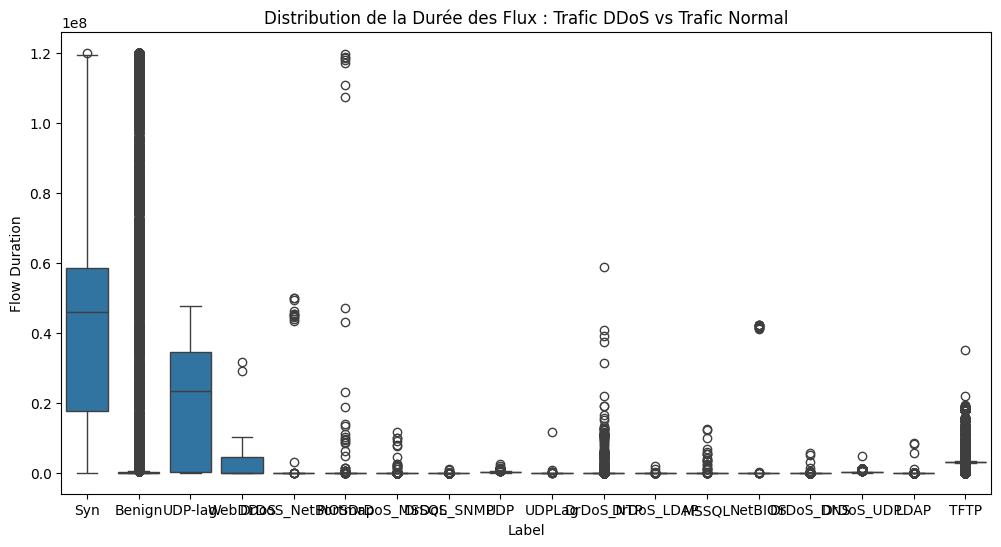

In [ ]:
# Boxplot de la durée des flux par type
plt.figure(figsize=(12, 6))
sns.boxplot(x="Label", y="Flow Duration", data=df)
plt.title("Distribution de la Durée des Flux : Trafic DDoS vs Trafic Normal")
plt.show()

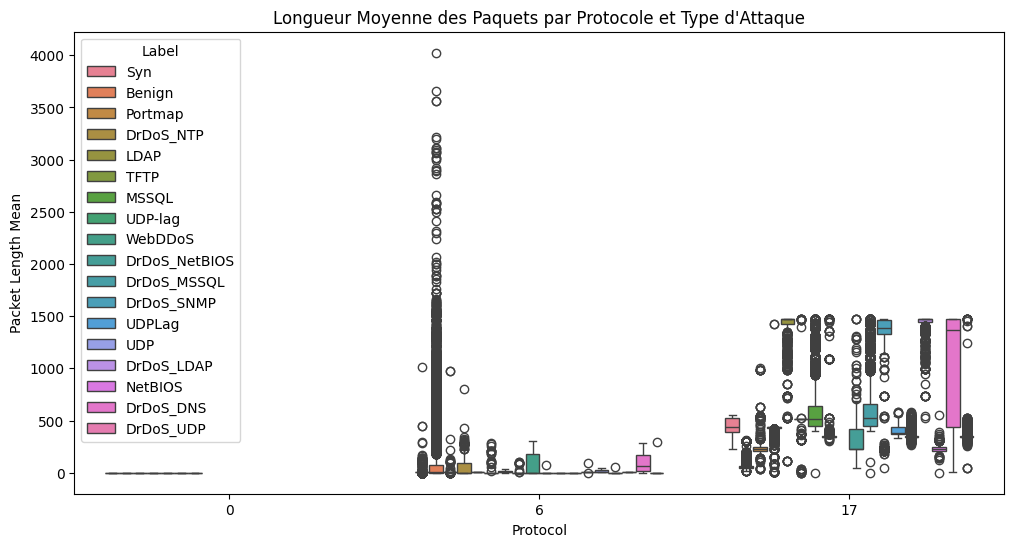

In [ ]:
# Boxplot de la taille moyenne des paquets par protocole et type de trafic
plt.figure(figsize=(12, 6))
sns.boxplot(x="Protocol", y="Packet Length Mean", hue="Label", data=df)
plt.title("Longueur Moyenne des Paquets par Protocole et Type d'Attaque")
plt.show()

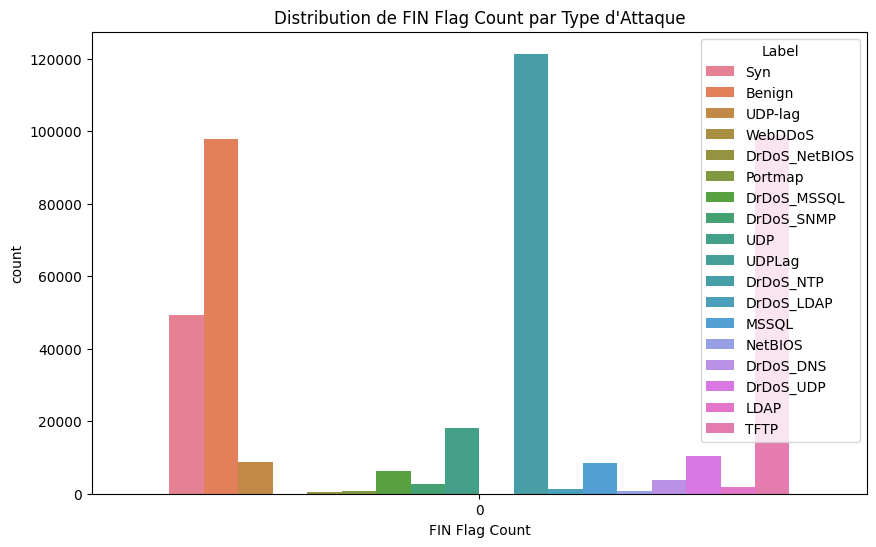

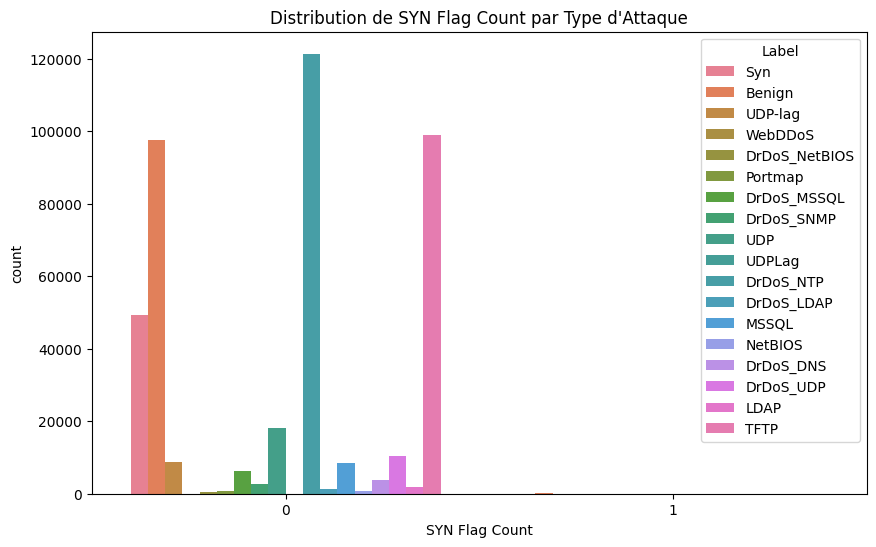

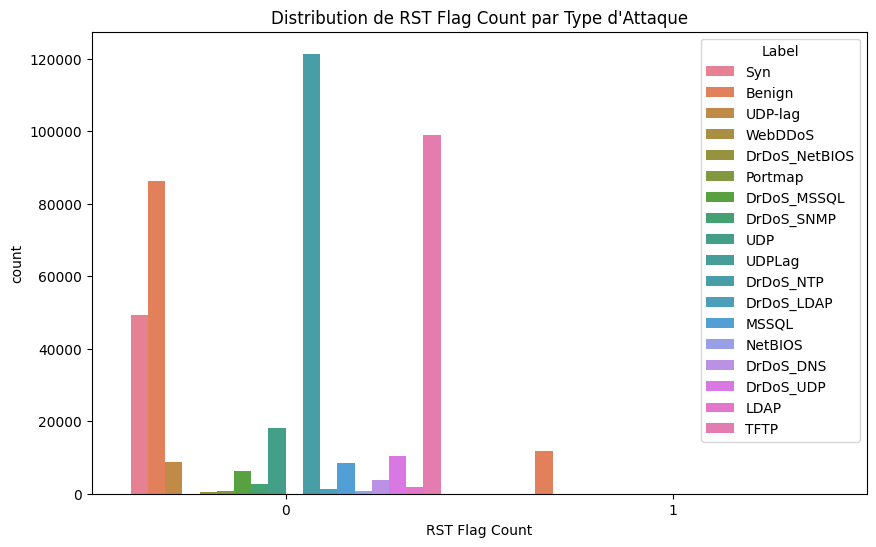

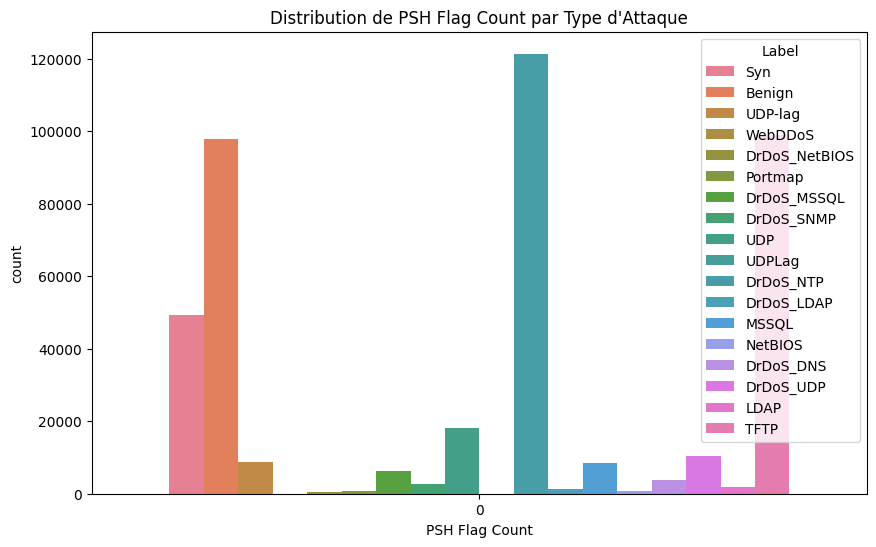

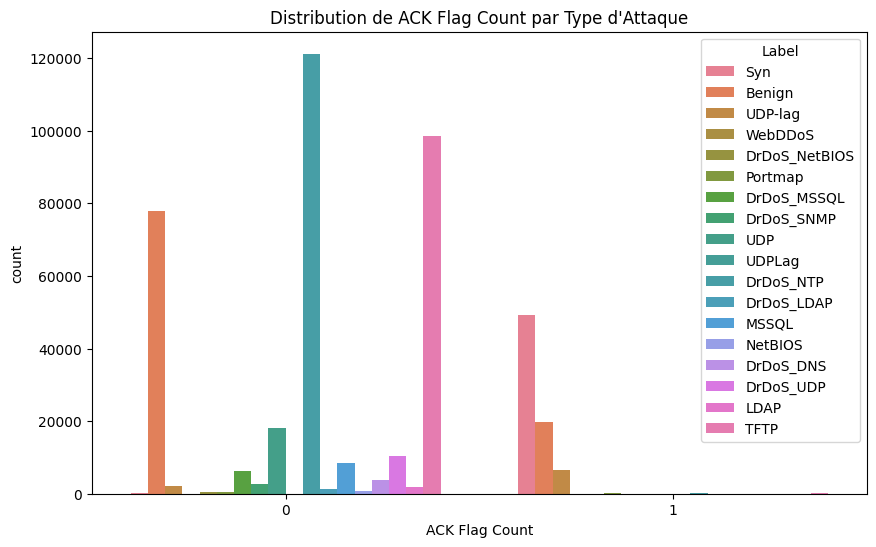

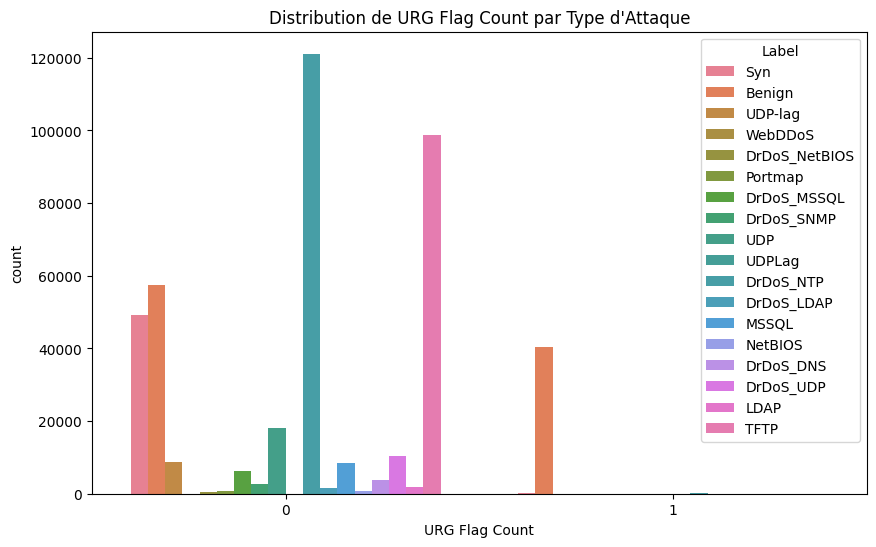

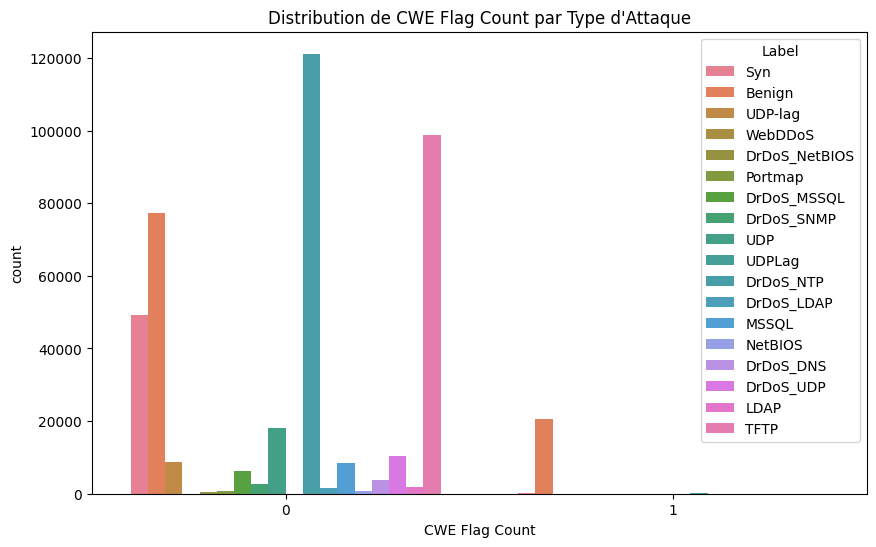

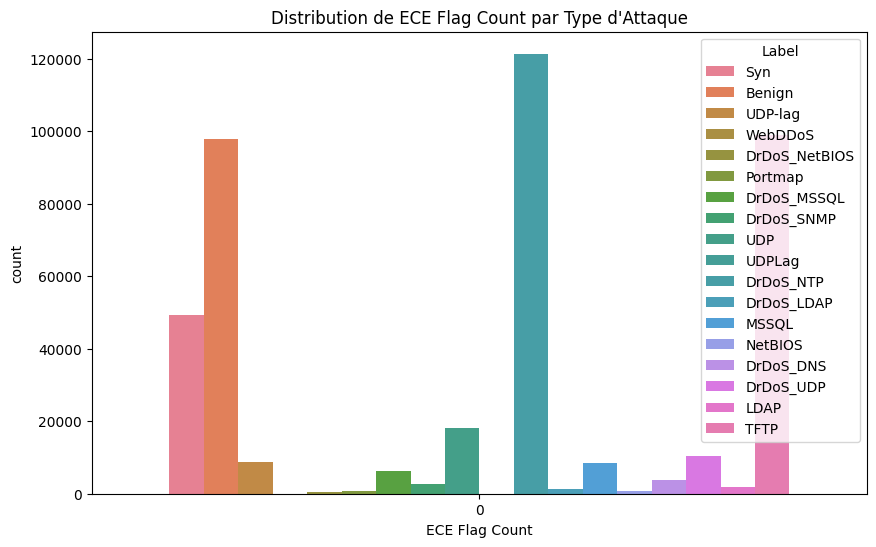

In [ ]:
# Compter le nombre d'occurrences de chaque flag dans le trafic attaque vs normal
colonnes_flags = [col for col in df.columns if "Flag " in col]

for flag in colonnes_flags:
    plt.figure(figsize=(10, 6))
    sns.countplot(x=flag, hue="Label", data=df)
    plt.title(f"Distribution de {flag} par Type d'Attaque")
    plt.show()

In [ ]:
X = data.drop(['outcome', 'Label'], axis=1)
y = data['outcome']

SelectKBest - 20 features sélectionnées


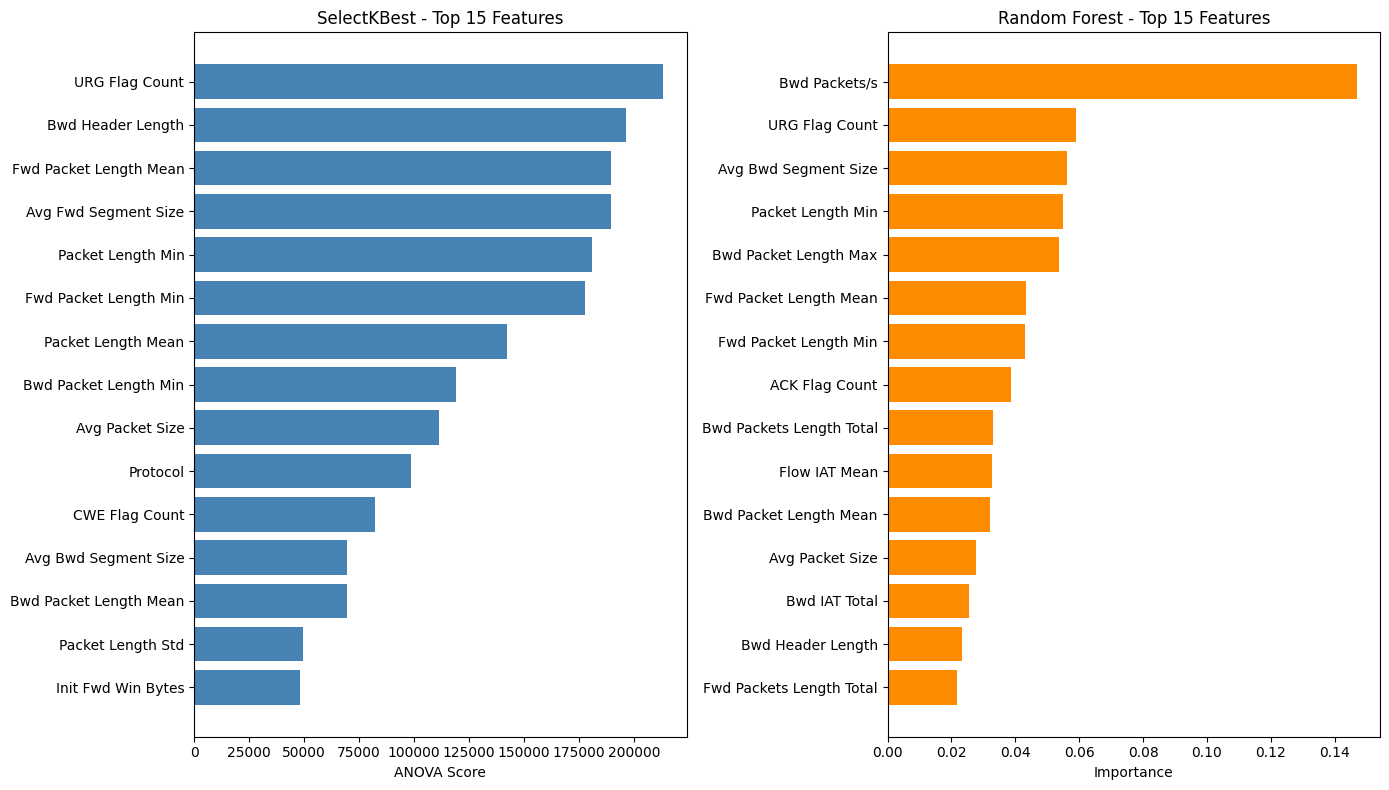


TOP 5 - SelectKBest
               Feature         Score
        URG Flag Count 213343.789486
     Bwd Header Length 196686.233991
Fwd Packet Length Mean 189539.777485
  Avg Fwd Segment Size 189539.777485
     Packet Length Min 181048.262272

TOP 5 - Random Forest
              Feature  Importance
        Bwd Packets/s    0.146866
       URG Flag Count    0.058990
 Avg Bwd Segment Size    0.056284
    Packet Length Min    0.055039
Bwd Packet Length Max    0.053726


In [ ]:

# FEATURE SELECTION : SelectKBest + Random Forest
N_FEATURES = 20

# Préparation des données
# 3. Refaire la sélection de features
feature_names = X.columns.tolist()
X_array = X.values.astype(np.float32)
y_array = y.values.astype(np.int32)
X_array = np.nan_to_num(X_array, nan=0, posinf=0, neginf=0)


# 1. SELECTKBEST

selector = SelectKBest(f_classif, k=min(N_FEATURES, X_array.shape[1]))
selector.fit(X_array, y_array)

selected_idx = selector.get_support(indices=True)

results_kbest = pd.DataFrame({
    'Feature': [feature_names[i] for i in selected_idx],
    'Score': selector.scores_[selected_idx]
}).sort_values('Score', ascending=False)

print(f"SelectKBest - {len(selected_idx)} features sélectionnées")

# 2. RANDOM FOREST

rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_array, y_array)

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:N_FEATURES]

results_rf = pd.DataFrame({
    'Feature': [feature_names[i] for i in indices],
    'Importance': importances[indices]
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

ax1.barh(results_kbest['Feature'][:15][::-1], results_kbest['Score'][:15][::-1], color='steelblue')
ax1.set_title('SelectKBest - Top 15 Features', fontsize=12)
ax1.set_xlabel('ANOVA Score')

ax2.barh(results_rf['Feature'][:15][::-1], results_rf['Importance'][:15][::-1], color='darkorange')
ax2.set_title('Random Forest - Top 15 Features', fontsize=12)
ax2.set_xlabel('Importance')

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("TOP 5 - SelectKBest")
print("="*50)
print(results_kbest.head().to_string(index=False))

print("\n" + "="*50)
print("TOP 5 - Random Forest")
print("="*50)
print(results_rf.head().to_string(index=False))

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Sélectionner uniquement les 20 meilleures features
X_selected = X_array[:, selected_idx]

# Récupérer les noms des features sélectionnées
selected_feature_names = [feature_names[i] for i in selected_idx]

# Créer le nouveau DataFrame
X_final = pd.DataFrame(X_selected, columns=selected_feature_names)
X_final['outcome'] = y_array
print(f"Shape final: {X_final.shape}")
print(X_final.head())

Shape final: (425697, 21)
   Protocol  Fwd Packet Length Max  Fwd Packet Length Min  \
0       1.0                    6.0                    6.0   
1       1.0                    6.0                    6.0   
2       1.0                    6.0                    6.0   
3       1.0                    6.0                    6.0   
4       1.0                    6.0                    6.0   

   Fwd Packet Length Mean  Bwd Packet Length Max  Bwd Packet Length Min  \
0                     6.0                    6.0                    6.0   
1                     6.0                    0.0                    0.0   
2                     6.0                    0.0                    0.0   
3                     6.0                    0.0                    0.0   
4                     6.0                    6.0                    6.0   

   Bwd Packet Length Mean  Bwd Packet Length Std  Fwd PSH Flags  \
0                     6.0                    0.0            0.0   
1                     

In [ ]:
X_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 425697 entries, 0 to 425696
Data columns (total 21 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Protocol                425697 non-null  float32
 1   Fwd Packet Length Max   425697 non-null  float32
 2   Fwd Packet Length Min   425697 non-null  float32
 3   Fwd Packet Length Mean  425697 non-null  float32
 4   Bwd Packet Length Max   425697 non-null  float32
 5   Bwd Packet Length Min   425697 non-null  float32
 6   Bwd Packet Length Mean  425697 non-null  float32
 7   Bwd Packet Length Std   425697 non-null  float32
 8   Fwd PSH Flags           425697 non-null  float32
 9   Bwd Header Length       425697 non-null  float32
 10  Packet Length Min       425697 non-null  float32
 11  Packet Length Mean      425697 non-null  float32
 12  Packet Length Std       425697 non-null  float32
 13  RST Flag Count          425697 non-null  float32
 14  URG Flag Count      

In [ ]:
print(X_final['outcome'].value_counts())

outcome
1    331101
0     94596
Name: count, dtype: int64


In [ ]:
from sklearn.utils import resample
# Séparer les classes
X = X_final.drop('outcome', axis=1)
y = X_final['outcome']

# Séparer les échantillons par classe
X_benign = X[y == 0]
X_attack = X[y == 1]

# Sous-échantillonner la classe majoritaire (attaques)
n_benign = len(X_benign)
X_attack_downsampled = resample(X_attack, n_samples=n_benign, random_state=42)

# Concaténer
X = pd.concat([X_benign, X_attack_downsampled])
y = pd.Series([0]*n_benign + [1]*n_benign)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
print(y.value_counts())

0    94596
1    94596
Name: count, dtype: int64


In [ ]:
# Normalisation
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## ***Evaluate ML Models Function***

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_classification(model, name, X_train, X_test, y_train, y_test):
    # Predictions
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    # Compute confusion matrix for both train and test sets
    train_confusion_matrix = metrics.confusion_matrix(y_train, train_pred)
    test_confusion_matrix = metrics.confusion_matrix(y_test, test_pred)

    # Calculate metrics
    train_accuracy = metrics.accuracy_score(y_train, train_pred)
    train_precision = metrics.precision_score(y_train, train_pred)
    train_recall = metrics.recall_score(y_train, train_pred)
    train_f1 = metrics.f1_score(y_train, train_pred)

    test_accuracy = metrics.accuracy_score(y_test, test_pred)
    test_precision = metrics.precision_score(y_test, test_pred)
    test_recall = metrics.recall_score(y_test, test_pred)
    test_f1 = metrics.f1_score(y_test, test_pred)

    # Print metrics
    print(f"Training Metrics for {name}:")
    print(f"Accuracy: {train_accuracy*100:.2f}%, Precision: {train_precision*100:.2f}%, Recall: {train_recall*100:.2f}%, F1 Score: {train_f1*100:.2f}%")
    print(f"Testing Metrics for {name}:")
    print(f"Accuracy: {test_accuracy*100:.2f}%, Precision: {test_precision*100:.2f}%, Recall: {test_recall*100:.2f}%, F1 Score: {test_f1*100:.2f}%")

    # Plot confusion matrix
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    sns.heatmap(train_confusion_matrix, annot=True, fmt='g')
    plt.title(f'Training Confusion Matrix for {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.subplot(1, 2, 2)
    sns.heatmap(test_confusion_matrix, annot=True, fmt='g')
    plt.title(f'Testing Confusion Matrix for {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.show()


## ***Models Training + evaluation + Confision Matrix***

In [ ]:
model_names = []
accuracies = []
f1_scores = []
execution_times = []

### Logistic Regression

Training Metrics for Logistic Regression:
Accuracy: 96.57%, Precision: 93.81%, Recall: 99.71%, F1 Score: 96.67%
Testing Metrics for Logistic Regression:
Accuracy: 96.73%, Precision: 94.07%, Recall: 99.74%, F1 Score: 96.82%


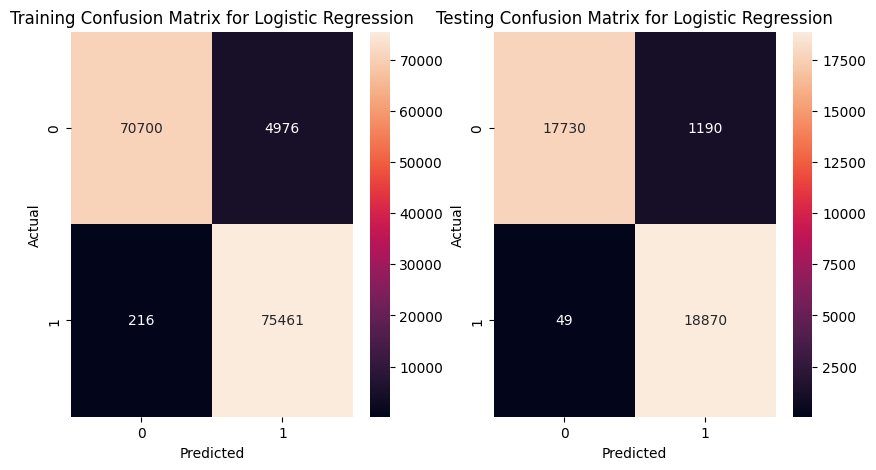

Temps d'exécution : 1.46 secondes


In [ ]:
import time
start = time.time()
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
end = time.time()
temp_lr= end-start
evaluate_classification(lr, "Logistic Regression", X_train, X_test, y_train, y_test)
print("Temps d'exécution :", round(temp_lr, 2), "secondes")

### Gaussian Naive Bayes

Training Metrics for GaussianNB:
Accuracy: 96.45%, Precision: 93.61%, Recall: 99.71%, F1 Score: 96.56%
Testing Metrics for GaussianNB:
Accuracy: 96.62%, Precision: 93.88%, Recall: 99.73%, F1 Score: 96.72%


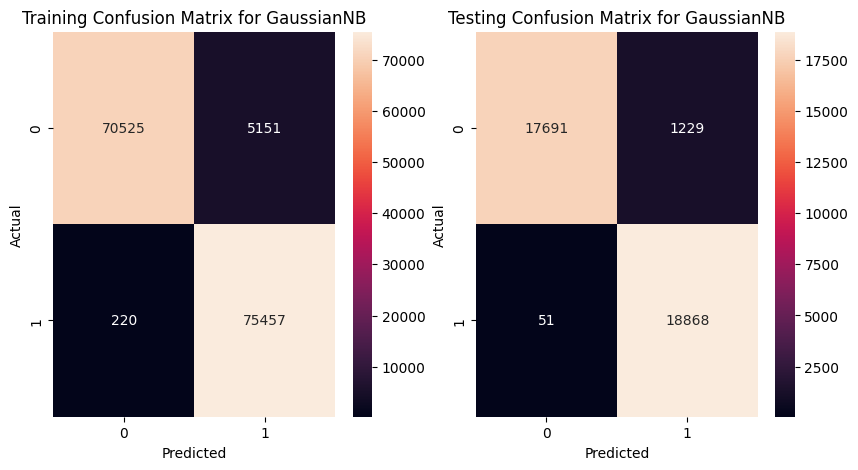

Temps d'exécution : 0.06 secondes


In [ ]:
import time
start = time.time()
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)
end = time.time()
temp_gnb = end - start
evaluate_classification(gnb,"GaussianNB",X_train,X_test,y_train,y_test)
print("Temps d'exécution :", round(temp_gnb, 2), "secondes")

### SVM

Training Metrics for Linear SVC:
Accuracy: 96.50%, Precision: 93.68%, Recall: 99.72%, F1 Score: 96.61%
Testing Metrics for Linear SVC:
Accuracy: 96.67%, Precision: 93.97%, Recall: 99.74%, F1 Score: 96.77%


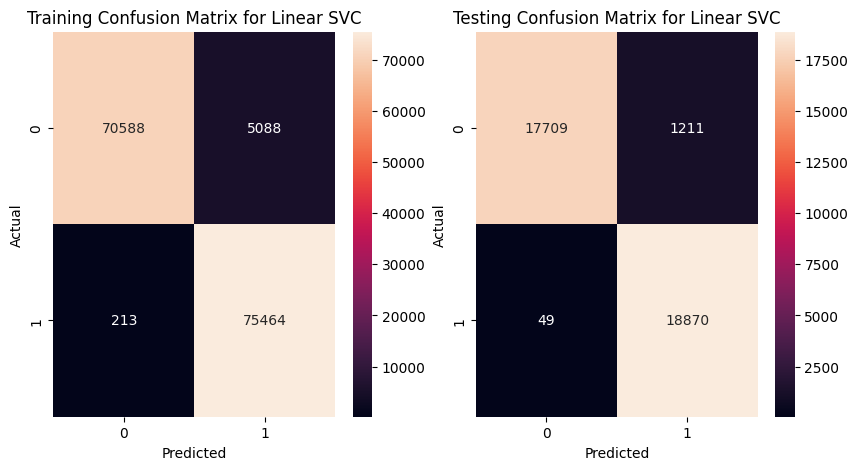

Temps d'exécution : 1.33 secondes


In [ ]:
import time

start = time.time()
lin_svc = svm.LinearSVC()
lin_svc.fit(X_train, y_train)
y_pred = lin_svc.predict(X_test)
end = time.time()
temp_svc = end - start
evaluate_classification( lin_svc, "Linear SVC", X_train, X_test, y_train, y_tes)
print("Temps d'exécution :", round(temp_svc, 2), "secondes")

### Random Forest

Training Metrics for Random Forest:
Accuracy: 99.95%, Precision: 99.97%, Recall: 99.93%, F1 Score: 99.95%
Testing Metrics for Random Forest:
Accuracy: 99.91%, Precision: 99.93%, Recall: 99.89%, F1 Score: 99.91%


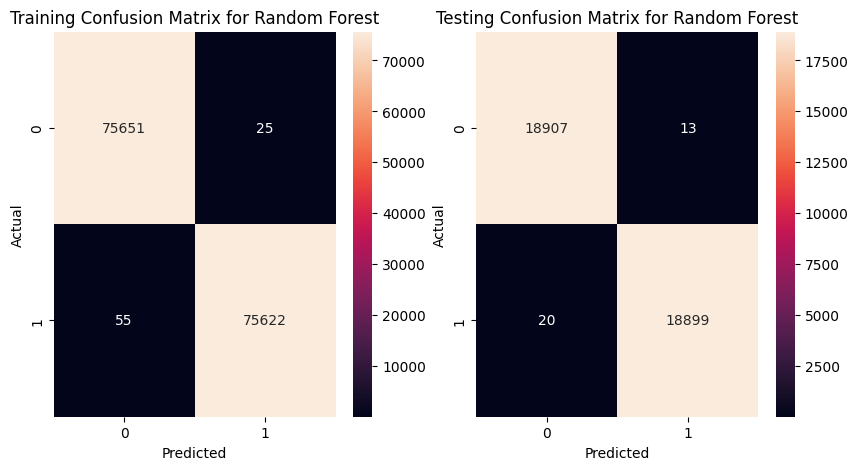

Temps d'exécution : 11.02 secondes


In [ ]:
import time
start = time.time()
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
end = time.time()
temp_rf = end - start
evaluate_classification(rf,"Random Forest",X_train,X_test,y_train,y_test)
print("Temps d'exécution :", round(temp_rf, 2), "secondes")

## ***MLP***

In [ ]:
start = time.time()
model = Sequential()
model.add(Dense(64,activation='relu',input_shape=(X_train.shape[1],)))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

## ***Standardize features***

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# COMPILATION
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# ENTRAINEMENT

history = model.fit(X_train,y_train,validation_split=0.2,epochs=20,batch_size=64,verbose=1)
end = time.time()
temp_mlp = end - start
print("Temps d'exécution :", round(temp_mlp, 2), "secondes")

Epoch 1/20
1892/1892 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9846 - loss: 0.0520 - val_accuracy: 0.9937 - val_loss: 0.0208
Epoch 2/20
1892/1892 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9963 - loss: 0.0171 - val_accuracy: 0.9970 - val_loss: 0.0135
Epoch 3/20
1892/1892 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9968 - loss: 0.0138 - val_accuracy: 0.9971 - val_loss: 0.0126
Epoch 4/20
1892/1892 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9970 - loss: 0.0120 - val_accuracy: 0.9973 - val_loss: 0.0120
Epoch 5/20
1892/1892 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9970 - loss: 0.0114 - val_accuracy: 0.9976 - val_loss: 0.0117
Epoch 6/20
1892/1892 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9972 - loss: 0.0107 - val_accuracy: 0.9976 - val_loss: 0.0109
Epoch 7/20
1892/1892 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9971 - loss: 0.0103 - val_accuracy: 0.9976 - val_loss: 0.0104
Epoch 8/20
1892/1892 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9973 - loss: 0.0101 -

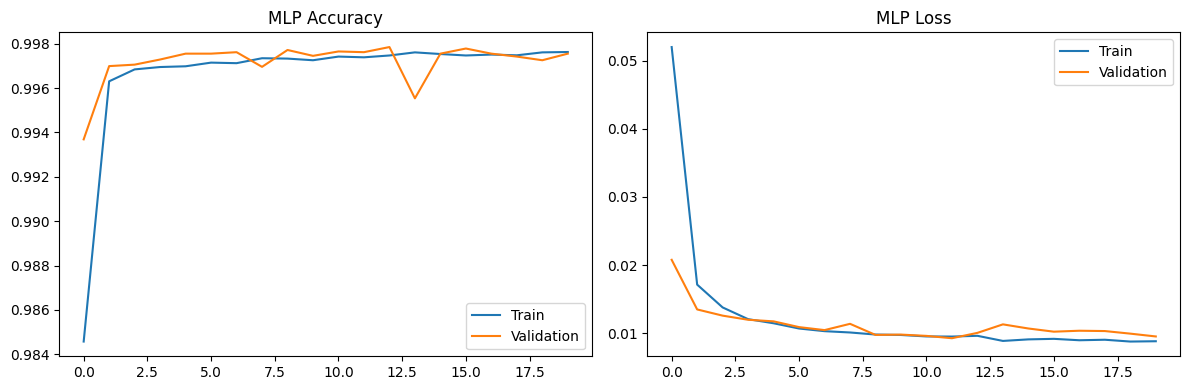

1183/1183 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

 MLP (Neural Network)
Accuracy : 99.77%
F1-Score : 99.77%


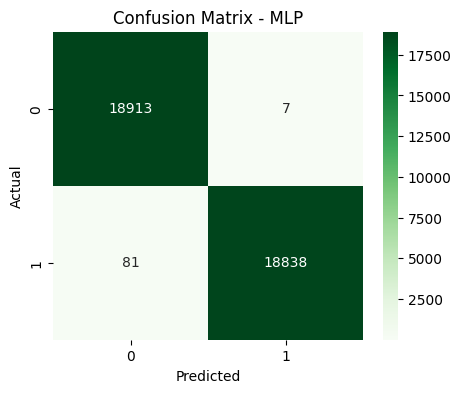

In [ ]:
# COURBES D'APPRENTISSAGE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
# Accuracy
ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('MLP Accuracy')
ax1.legend()
# Loss
ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('MLP Loss')
ax2.legend()
plt.tight_layout()
plt.show()
# PREDICTIONS
y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()
# METRIQUES
mlp_acc = accuracy_score(y_test, y_pred)
mlp_f1 = f1_score(y_test, y_pred)
print("\n MLP (Neural Network)")
print("="*50)
print(f"Accuracy : {mlp_acc*100:.2f}%")
print(f"F1-Score : {mlp_f1*100:.2f}%")
# MATRICE DE CONFUSION
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Greens')
plt.title('Confusion Matrix - MLP')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## ***CNN Model Training***

In [ ]:
x_train_cnn = X_train.reshape( X_train.shape[0], X_train.shape[1], 1)
x_test_cnn = X_test.reshape(X_test.shape[0],X_test.shape[1], 1)

In [ ]:
start = time.time()
cnn_model = Sequential()

# Couche convolution
cnn_model.add(Conv1D(filters=32,kernel_size=3,activation='relu',input_shape=(X_train.shape[1], 1)))
# Pooling
cnn_model.add(MaxPooling1D(pool_size=2))
# Flatten
cnn_model.add(Flatten())
# Dense
cnn_model.add(Dense(64, activation='relu'))
cnn_model.add(Dropout(0.3))
# Sortie
cnn_model.add(Dense(1, activation='sigmoid'))

In [ ]:
# COMPILATION
cnn_model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
# ENTRAINEMENT
history_cnn = cnn_model.fit(x_train_cnn,y_train,validation_split=0.2,epochs=20,batch_size=64,verbose=1)
end = time.time()
temp_cnn = end - start
print("CNN Accuracy :", accuracy_score(y_test, y_pred))
print("CNN F1-Score :", f1_score(y_test, y_pred))

print("Temps d'exécution :", round(temp_cnn, 2), "secondes")

Epoch 1/20
1892/1892 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9823 - loss: 0.0587 - val_accuracy: 0.9954 - val_loss: 0.0237
Epoch 2/20
1892/1892 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9952 - loss: 0.0218 - val_accuracy: 0.9956 - val_loss: 0.0167
Epoch 3/20
1892/1892 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9962 - loss: 0.0168 - val_accuracy: 0.9968 - val_loss: 0.0142
Epoch 4/20
1892/1892 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9966 - loss: 0.0154 - val_accuracy: 0.9969 - val_loss: 0.0132
Epoch 5/20
1892/1892 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9968 - loss: 0.0142 - val_accuracy: 0.9971 - val_loss: 0.0126
Epoch 6/20
1892/1892 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9970 - loss: 0.0132 - val_accuracy: 0.9975 - val_loss: 0.0127
Epoch 7/20
1892/1892 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9969 - loss: 0.0125 - val_accuracy: 0.9974 - val_loss: 0.0110
Epoch 8/20
1892/1892 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9971 - loss: 0.0119 -

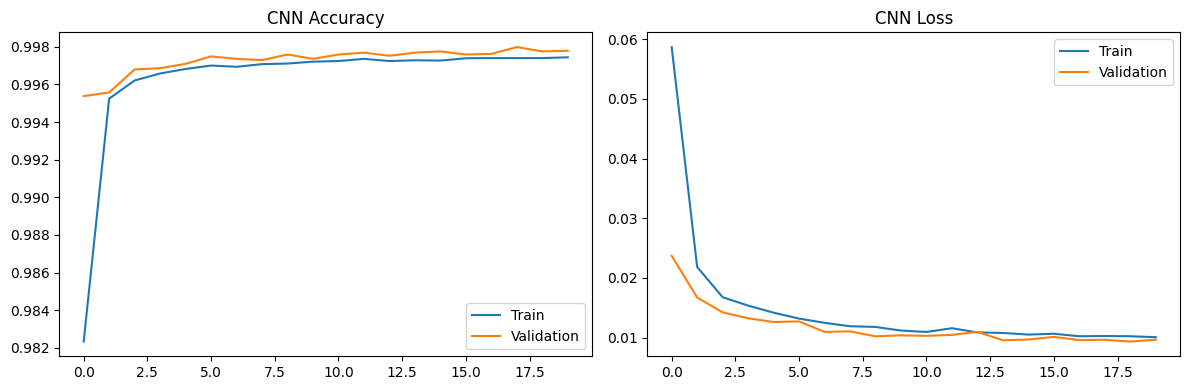

1183/1183 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step

 CNN Model
Accuracy : 99.80%
F1-Score : 99.80%


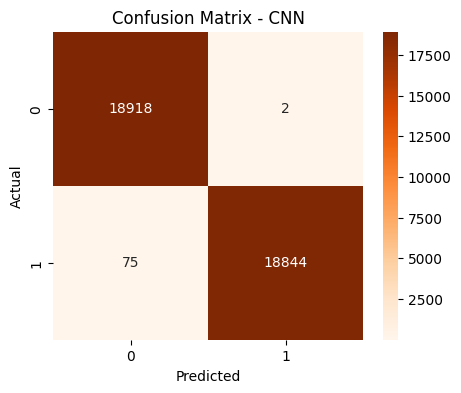

In [ ]:
# =========================================================
# COURBES D'APPRENTISSAGE
# =========================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
# Accuracy
ax1.plot(history_cnn.history['accuracy'], label='Train')
ax1.plot(history_cnn.history['val_accuracy'], label='Validation')
ax1.set_title('CNN Accuracy')
ax1.legend()
# Loss
ax2.plot(history_cnn.history['loss'], label='Train')
ax2.plot(history_cnn.history['val_loss'], label='Validation')
ax2.set_title('CNN Loss')
ax2.legend()
plt.tight_layout()
plt.show()
# PREDICTIONS
cnn_pred = (cnn_model.predict(x_test_cnn) > 0.5).astype(int).flatten()
# METRIQUES
cnn_acc = accuracy_score(y_test, cnn_pred)
cnn_f1 = f1_score(y_test, cnn_pred)
print("\n CNN Model")
print("="*50)
print(f"Accuracy : {cnn_acc*100:.2f}%")
print(f"F1-Score : {cnn_f1*100:.2f}%")
# MATRICE DE CONFUSION
cm = confusion_matrix(y_test, cnn_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Oranges')
plt.title('Confusion Matrix - CNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

MODELE HYBRIDE CNN-LSTM

Epoch 1/10
1892/1892 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - accuracy: 0.9805 - loss: 0.0641 - val_accuracy: 0.9953 - val_loss: 0.0184
Epoch 2/10
1892/1892 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9959 - loss: 0.0175 - val_accuracy: 0.9942 - val_loss: 0.0211
Epoch 3/10
1892/1892 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9963 - loss: 0.0149 - val_accuracy: 0.9966 - val_loss: 0.0131
Epoch 4/10
1892/1892 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9965 - loss: 0.0132 - val_accuracy: 0.9968 - val_loss: 0.0130
Epoch 5/10
1892/1892 ━━━━━━━━━━━━━━━━━━━━ 46s 16ms/step - accuracy: 0.9964 - loss: 0.0129 - val_accuracy: 0.9972 - val_loss: 0.0127
Epoch 6/10
1892/1892 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9966 - loss: 0.0124 - val_accuracy: 0.9974 - val_loss: 0.0116
Epoch 7/10
1892/1892 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - accuracy: 0.9966 - loss: 0.0121 - val_accuracy: 0.9972 - val_loss: 0.0113
Epoch 8/10
1892/1892 ━━━━━━━━━━━━━━━━━━━━ 42s 22ms/step - accuracy: 0.9969 -

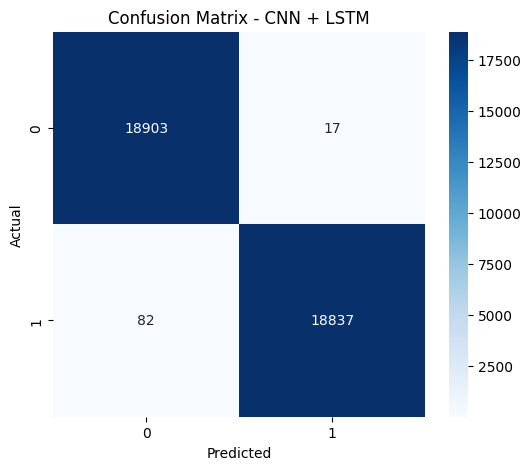

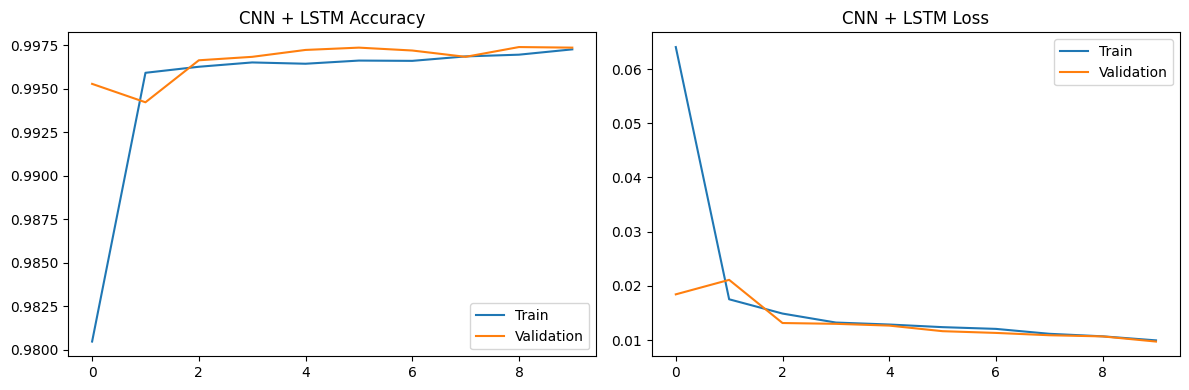

In [ ]:
X_train_cnn = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_cnn = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

start = time.time()
cnn_lstm = Sequential()
# CNN
cnn_lstm.add(Conv1D( filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)))
cnn_lstm.add(MaxPooling1D(pool_size=2))

# LSTM
cnn_lstm.add(LSTM(64))
# Dense
cnn_lstm.add(Dense(64, activation='relu'))
cnn_lstm.add(Dropout(0.3))

# Output
cnn_lstm.add(Dense(1, activation='sigmoid'))

cnn_lstm.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy'])

history_cnn_lstm = cnn_lstm.fit( X_train_cnn, y_train, validation_split=0.2, epochs=10, batch_size=64, verbose=1)
end = time.time()

temp_cnn_lstm = end - start
cnn_lstm_pred = (cnn_lstm.predict(X_test_cnn) > 0.5).astype("int32")

cnn_lstm_acc = accuracy_score(y_test, cnn_lstm_pred)
cnn_lstm_f1 = f1_score(y_test, cnn_lstm_pred)

print("\n CNN + LSTM")
print("="*50)
print(f"Accuracy : {cnn_lstm_acc*100:.2f}%")
print(f"F1-Score : {cnn_lstm_f1*100:.2f}%")
print("Temps d'exécution :", round(temp_cnn_lstm, 2), "secondes")

cm = confusion_matrix(y_test, cnn_lstm_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues'
)

plt.title("Confusion Matrix - CNN + LSTM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
ax1.plot(history_cnn_lstm.history['accuracy'], label='Train')
ax1.plot(history_cnn_lstm.history['val_accuracy'], label='Validation')
ax1.set_title('CNN + LSTM Accuracy')
ax1.legend()
# Loss
ax2.plot(history_cnn_lstm.history['loss'], label='Train')
ax2.plot(history_cnn_lstm.history['val_loss'], label='Validation')

ax2.set_title('CNN + LSTM Loss')
ax2.legend()
plt.tight_layout()
plt.show()

1183/1183 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step

RÉSULTATS DES MODÈLES
              Modèle  Accuracy  Precision    Recall  F1-Score
Logistic\nRegression 96.725601  94.067797 99.741001 96.821365
         Gaussian NB 96.617247  93.884659 99.730430 96.719295
          Linear SVC 96.670102  93.969424 99.741001 96.769231
      Random\nForest 99.912788  99.931261 99.894286 99.912770
                 MLP 99.767436  99.962855 99.571859 99.766974
                 CNN 99.796506  99.989388 99.603573 99.796108
            CNN-LSTM 99.738365  99.909833 99.566573 99.737908

Échelle Y : 88.9% — 102%


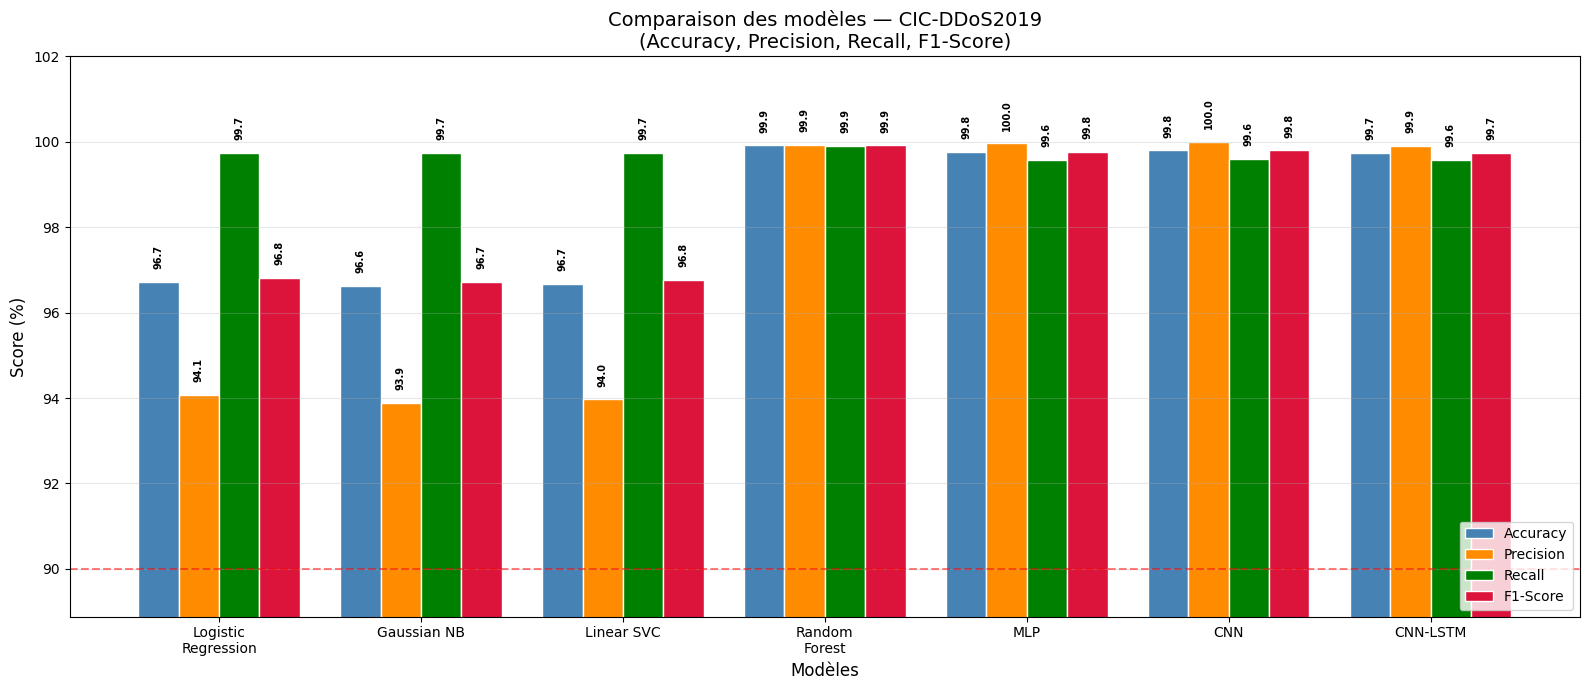

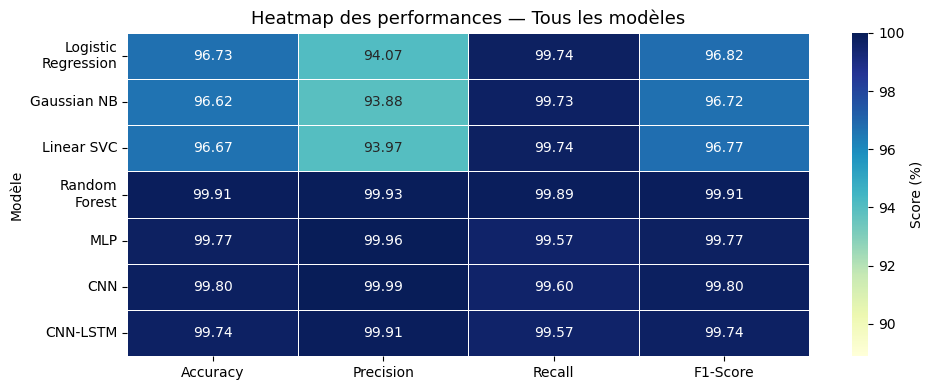

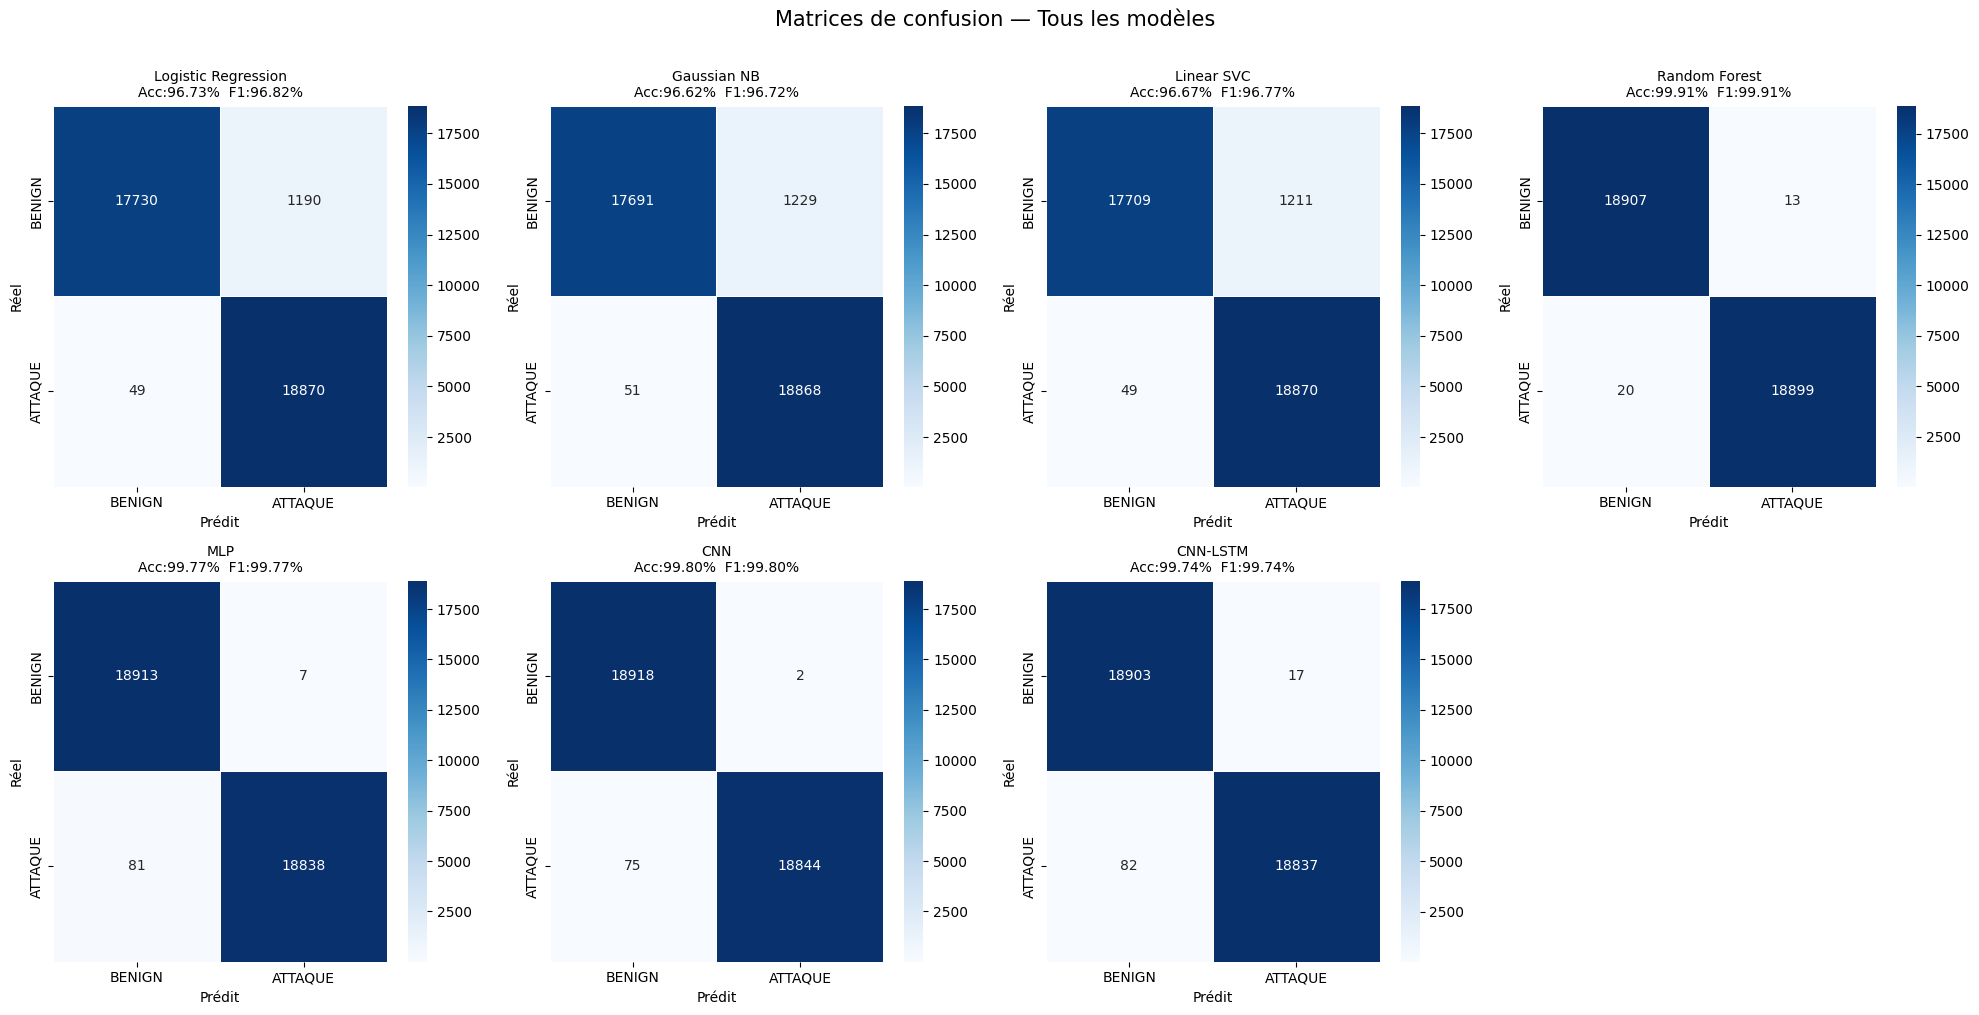

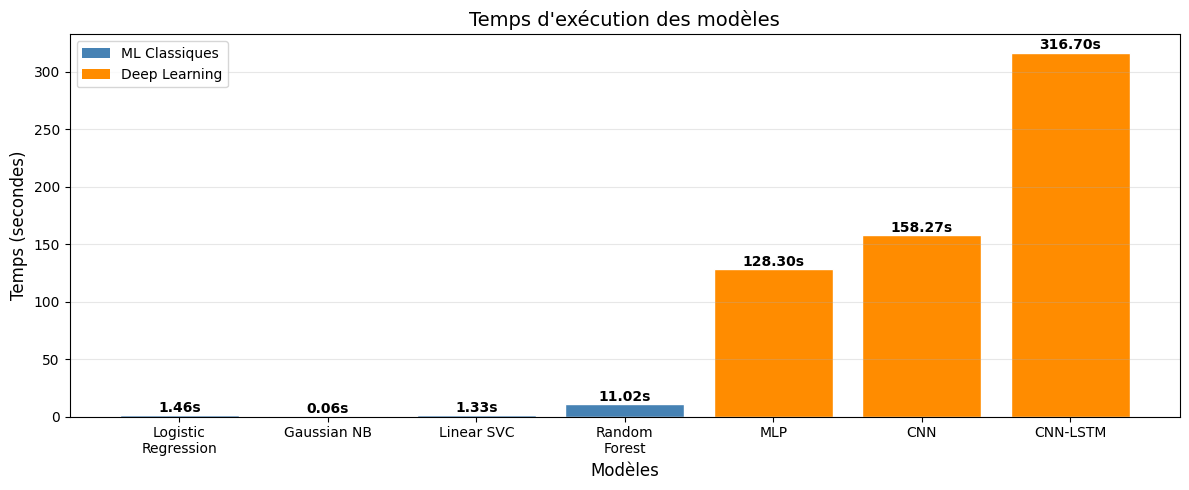


✅ VISUALISATION TERMINÉE


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# ── Prédictions ──────────────────────────────────────────
lr_pred  = lr.predict(X_test)
gnb_pred = gnb.predict(X_test)
svc_pred = lin_svc.predict(X_test)
rf_pred  = rf.predict(X_test)

mlp_pred = (model.predict(X_test) > 0.5).astype(int).flatten()

cnn_pred = (
    cnn_model.predict(X_test_cnn) > 0.5
).astype(int).flatten()

cnn_lstm_pred = (
    cnn_lstm.predict(X_test_cnn) > 0.5
).astype(int).flatten()

results = pd.DataFrame({
    'Modèle': [
        'Logistic\nRegression',
        'Gaussian NB',
        'Linear SVC',
        'Random\nForest',
        'MLP',
        'CNN',
        'CNN-LSTM'
    ],
    'Accuracy' : [
        accuracy_score(y_test, lr_pred)       * 100,
        accuracy_score(y_test, gnb_pred)      * 100,
        accuracy_score(y_test, svc_pred)      * 100,
        accuracy_score(y_test, rf_pred)       * 100,
        accuracy_score(y_test, mlp_pred)      * 100,
        accuracy_score(y_test, cnn_pred)      * 100,
        accuracy_score(y_test, cnn_lstm_pred) * 100,
    ],
    'Precision': [
        precision_score(y_test, lr_pred,       zero_division=0) * 100,
        precision_score(y_test, gnb_pred,      zero_division=0) * 100,
        precision_score(y_test, svc_pred,      zero_division=0) * 100,
        precision_score(y_test, rf_pred,       zero_division=0) * 100,
        precision_score(y_test, mlp_pred,      zero_division=0) * 100,
        precision_score(y_test, cnn_pred,      zero_division=0) * 100,
        precision_score(y_test, cnn_lstm_pred, zero_division=0) * 100,
    ],
    'Recall'   : [
        recall_score(y_test, lr_pred,       zero_division=0) * 100,
        recall_score(y_test, gnb_pred,      zero_division=0) * 100,
        recall_score(y_test, svc_pred,      zero_division=0) * 100,
        recall_score(y_test, rf_pred,       zero_division=0) * 100,
        recall_score(y_test, mlp_pred,      zero_division=0) * 100,
        recall_score(y_test, cnn_pred,      zero_division=0) * 100,
        recall_score(y_test, cnn_lstm_pred, zero_division=0) * 100,
    ],
    'F1-Score' : [
        f1_score(y_test, lr_pred,       zero_division=0) * 100,
        f1_score(y_test, gnb_pred,      zero_division=0) * 100,
        f1_score(y_test, svc_pred,      zero_division=0) * 100,
        f1_score(y_test, rf_pred,       zero_division=0) * 100,
        f1_score(y_test, mlp_pred,      zero_division=0) * 100,
        f1_score(y_test, cnn_pred,      zero_division=0) * 100,
        f1_score(y_test, cnn_lstm_pred, zero_division=0) * 100,
    ],
})

print("\n" + "=" * 70)
print("RÉSULTATS DES MODÈLES")
print("=" * 70)
print(results.to_string(index=False))

min_score = results[['Accuracy','Precision','Recall','F1-Score']].min().min()
y_min     = max(0, min_score - 5)
y_max     = 102

print(f"\nÉchelle Y : {y_min:.1f}% — {y_max}%")
fig, ax = plt.subplots(figsize=(16, 7))
x_pos = np.arange(len(results))
width = 0.2

bars1 = ax.bar(x_pos - 1.5*width, results['Accuracy'],
               width, label='Accuracy',   color='steelblue',  edgecolor='white')
bars2 = ax.bar(x_pos - 0.5*width, results['Precision'],
               width, label='Precision',  color='darkorange',  edgecolor='white')
bars3 = ax.bar(x_pos + 0.5*width, results['Recall'],
               width, label='Recall',     color='green',       edgecolor='white')
bars4 = ax.bar(x_pos + 1.5*width, results['F1-Score'],
               width, label='F1-Score',   color='crimson',     edgecolor='white')

# Valeurs sur les barres
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2.,
            height + 0.3,
            f'{height:.1f}',
            ha='center', va='bottom',
            fontsize=7, rotation=90,
            fontweight='bold'
        )

ax.set_xlabel('Modèles', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Comparaison des modèles — CIC-DDoS2019\n(Accuracy, Precision, Recall, F1-Score)',
             fontsize=14)
ax.set_xticks(x_pos)
ax.set_xticklabels(results['Modèle'], fontsize=10)
ax.legend(loc='lower right', fontsize=10)
ax.set_ylim([y_min, y_max])
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=90, color='red', linestyle='--',
           alpha=0.5, label='Seuil 90%')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))

heatmap_data = results.set_index('Modèle')[
    ['Accuracy', 'Precision', 'Recall', 'F1-Score']
]

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu',
    ax=ax,
    linewidths=0.5,
    vmin=y_min,
    vmax=100,
    cbar_kws={'label': 'Score (%)'}
)
ax.set_title('Heatmap des performances — Tous les modèles',
             fontsize=13)
ax.set_xlabel('')
plt.tight_layout()
plt.show()
all_preds = [
    ('Logistic Regression', lr_pred),
    ('Gaussian NB',         gnb_pred),
    ('Linear SVC',          svc_pred),
    ('Random Forest',       rf_pred),
    ('MLP',                 mlp_pred),
    ('CNN',                 cnn_pred),
    ('CNN-LSTM',            cnn_lstm_pred),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(all_preds):
    cm  = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred) * 100
    f1  = f1_score(y_test, y_pred, zero_division=0) * 100

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=axes[i],
        xticklabels=['BENIGN', 'ATTAQUE'],
        yticklabels=['BENIGN', 'ATTAQUE'],
        linewidths=0.5
    )
    axes[i].set_title(f'{name}\nAcc:{acc:.2f}%  F1:{f1:.2f}%',
                       fontsize=10)
    axes[i].set_xlabel('Prédit')
    axes[i].set_ylabel('Réel')

axes[7].set_visible(False)

plt.suptitle('Matrices de confusion — Tous les modèles',
             fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))

colors = ['steelblue', 'steelblue', 'steelblue', 'steelblue',
          'darkorange', 'darkorange', 'darkorange']

bars = ax.bar(results['Modèle'],
              [temp_lr, temp_gnb, temp_svc, temp_rf,
               temp_mlp, temp_cnn, temp_cnn_lstm],
              color=colors,
              edgecolor='white')

for bar in bars:
    yval = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.,
        yval + 0.1,
        f'{yval:.2f}s',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

ax.set_title("Temps d'exécution des modèles", fontsize=14)
ax.set_ylabel("Temps (secondes)", fontsize=12)
ax.set_xlabel("Modèles", fontsize=12)
ax.grid(axis='y', alpha=0.3)

# Légende manuelle
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue',  label='ML Classiques'),
    Patch(facecolor='darkorange', label='Deep Learning'),
]
ax.legend(handles=legend_elements, fontsize=10)

plt.tight_layout()
plt.show()


## ***Optimisation avec RandomizedSearchCV***

In [ ]:
import numpy as np
from sklearn.model_selection import ParameterGrid
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

param_grid = {
    'units1': [128, 256],
    'units2': [64, 128],
    'learning_rate': [0.001, 0.0005],
    'dropout_rate': [0.2, 0.3],
    'batch_size': [32, 64],
    'epochs': [20]  # Fixé, EarlyStopping arrêtera avant
}

best_score = 0
best_params = {}
best_model = None

print("Recherche des meilleurs hyperparamètres...")


total = len(list(ParameterGrid(param_grid)))
print(f"Total combinaisons: {total}\n")

for i, params in enumerate(ParameterGrid(param_grid)):
    print(f"[{i+1}/{total}] Test: units1={params['units1']}, units2={params['units2']}, "
          f"lr={params['learning_rate']}, dropout={params['dropout_rate']}, "
          f"batch={params['batch_size']}")
    model = Sequential()
    model.add(Dense(params['units1'], activation='relu', input_shape=(X_train.shape[1],)))
    model.add(Dropout(params['dropout_rate']))
    model.add(Dense(params['units2'], activation='relu'))
    model.add(Dropout(params['dropout_rate']))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=Adam(learning_rate=params['learning_rate']),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    # Early stopping
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    # Entraînement
    history = model.fit(
        X_train, y_train,
        batch_size=params['batch_size'],
        epochs=params['epochs'],
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0
    )

    val_acc = max(history.history['val_accuracy'])
    print(f"  → Validation accuracy: {val_acc:.4f}")

    if val_acc > best_score:
        best_score = val_acc
        best_params = params
        best_model = model
        print(f" NOUVEAU MEILLEUR ")

print(f"Meilleure accuracy: {best_score:.4f} ({best_score*100:.2f}%)")
print(f"Meilleurs paramètres: {best_params}")

# Évaluation sur test
y_pred = (best_model.predict(X_test) > 0.5).astype(int)
test_acc = accuracy_score(y_test, y_pred)
print(f"\n Test accuracy avec meilleur modèle: {test_acc*100:.2f}%")

🔍 Recherche des meilleurs hyperparamètres...
Total combinaisons: 32

[1/32] Test: units1=128, units2=64, lr=0.001, dropout=0.2, batch=32
  → Validation accuracy: 0.9977
  ✅ NOUVEAU MEILLEUR !
[2/32] Test: units1=128, units2=128, lr=0.001, dropout=0.2, batch=32
  → Validation accuracy: 0.9976
[3/32] Test: units1=256, units2=64, lr=0.001, dropout=0.2, batch=32
  → Validation accuracy: 0.9975
[4/32] Test: units1=256, units2=128, lr=0.001, dropout=0.2, batch=32
  → Validation accuracy: 0.9978
  ✅ NOUVEAU MEILLEUR !
[5/32] Test: units1=128, units2=64, lr=0.0005, dropout=0.2, batch=32
  → Validation accuracy: 0.9978
  ✅ NOUVEAU MEILLEUR !
[6/32] Test: units1=128, units2=128, lr=0.0005, dropout=0.2, batch=32
  → Validation accuracy: 0.9979
  ✅ NOUVEAU MEILLEUR !
[7/32] Test: units1=256, units2=64, lr=0.0005, dropout=0.2, batch=32
  → Validation accuracy: 0.9979
[8/32] Test: units1=256, units2=128, lr=0.0005, dropout=0.2, batch=32
  → Validation accuracy: 0.9978
[9/32] Test: units1=128, units2